# Notebook 01: Data Exploration and Data Quality Review

**Project:** MAP Dryer AI  
**Purpose:** establish a trustworthy view of the raw MAP dryer dataset before feature engineering or model development.

This notebook loads the prototype dryer records, checks that the expected process variables are present, removes exact duplicate rows, and reviews the resulting numeric distributions.

## Inputs and outputs

- **Input:** `data/raw/dryerMAP_prototype.xlsx`
- **Processed output:** `data/processed/dryerMAP_prototype_deduplicated.xlsx`
- **Figure output:** `figures/01_Data_Exploration/01_numeric_feature_distributions.png`

## Reading guide

Run the cells in order. The notebook is descriptive: it documents data quality and distributions, but does not train a model. Notebook 02 uses the deduplicated output created here.

## 1. Environment and display settings

Import the packages used for data preparation and visualisation, then set consistent display defaults for the exploratory work.

In [1]:
from pathlib import Path
import platform
import re
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from scipy import stats
import openpyxl

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print(f"Python: {platform.python_version()}")


Python: 3.14.6


## 2. Locate the project and load the raw data

The project root is found dynamically so the notebook can be launched from the repository root or from the `notebooks/` directory. The raw Excel file is loaded through the shared cleaning helper before its columns and first records are displayed.

In [2]:
SRC_DIR = next(candidate / "src" for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "data" / "raw").is_dir())
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from data.project_paths import find_project_root
from data.data_cleaning import prepare_dryer_map
PROJECT_ROOT = find_project_root()
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURE_OUTPUT_DIR = FIGURES_DIR / "01_Data_Exploration"
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "dryerMAP_prototype_2.xlsx"
dryerMAP = prepare_dryer_map(pd.read_excel(DATA_PATH))
print(f"Loaded {DATA_PATH}")
print(dryerMAP.columns.tolist())
dryerMAP.head(10)

Loaded c:\Users\pc\Documents\GitHub\PROJECTS\MAP-Dryer-AI\data\raw\dryerMAP_prototype_2.xlsx
['date', 'time', 'dryer_air_temperature', 'cooler_air_temperature', 'air_flow_rate', 'wet_product_feed_rate', 'product_inlet_temperature', 'residence_time', 'vacuum', 'steam_pressure', 'fan_speed', 'product_density', 'final_product_temp', 'final_moisture_h₂o', 'timestamp']


c:\Users\pc\Documents\GitHub\PROJECTS\MAP-Dryer-AI\src\data\data_cleaning.py:72: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(


,date,time,dryer_air_temperature,cooler_air_temperature,air_flow_rate,wet_product_feed_rate,product_inlet_temperature,residence_time,vacuum,steam_pressure,fan_speed,product_density,final_product_temp,final_moisture_h₂o,timestamp
0,2026-04-23,01:00:00,139.0,23.2,23.62,10.0,47.7,20.96,-1.18,4.69,1270,1.023,41.0,0.075,2026-04-23 01:00:00
1,2026-04-23,03:00:00,139.7,21.4,24.32,10.2,46.6,20.29,-0.63,4.78,1236,1.028,43.7,0.087,2026-04-23 03:00:00
2,2026-04-23,05:00:00,140.1,18.9,23.8,10.25,47.3,20.36,-1.08,4.81,1272,1.034,45.7,0.072,2026-04-23 05:00:00
3,2026-04-23,07:00:00,139.7,18.5,23.35,10.27,48.1,20.25,-0.65,4.77,1238,1.033,45.2,0.094,2026-04-23 07:00:00
4,2026-04-23,09:00:00,139.8,19.0,23.44,10.35,46.5,20.99,-1.1,4.84,1267,1.025,42.9,0.084,2026-04-23 09:00:00
5,2026-04-23,11:00:00,140.7,18.7,24.08,10.39,45.6,20.76,-1.05,5.11,1270,1.033,47.8,0.075,2026-04-23 11:00:00
6,2026-04-23,13:00:00,140.5,19.7,24.0,10.44,47.9,20.74,-1.15,5.0,1282,1.032,49.1,0.07,2026-04-23 13:00:00
7,2026-04-23,15:00:00,139.6,22.0,24.36,10.43,47.9,21.02,-1.18,4.86,1291,1.026,46.3,0.073,2026-04-23 15:00:00
8,2026-04-23,17:00:00,140.2,23.7,24.47,10.32,48.6,21.73,-1.23,4.9,1274,1.037,46.1,0.052,2026-04-23 17:00:00
9,2026-04-23,19:00:00,140.7,24.8,24.06,10.21,49.6,20.3,-1.0,4.89,1265,1.025,44.5,0.065,2026-04-23 19:00:00


## 3. Validate the schema and remove exact duplicates

The analysis expects 14 ordered process and quality columns. This step verifies that schema, counts missing values and duplicate rows, removes only exact duplicates, and saves the deduplicated dataset for the next notebook.

In [3]:
expected_columns = ['date', 'time', 'dryer_air_temperature', 'cooler_air_temperature', 'air_flow_rate', 'wet_product_feed_rate', 'product_inlet_temperature', 'residence_time', 'vacuum', 'steam_pressure', 'fan_speed', 'product_density', 'final_product_temp', 'final_moisture_h₂o']
assert dryerMAP.columns[:len(expected_columns)].tolist() == expected_columns, "Unexpected dataset schema."

duplicate_count = int(dryerMAP.duplicated().sum())
dryerMAP_unique = dryerMAP.drop_duplicates().reset_index(drop=True)
dryerMAP_unique.to_excel(PROCESSED_DIR / "dryerMAP_prototype_deduplicated_2.xlsx", index=False)
validation_summary = pd.Series({
    "rows_raw": len(dryerMAP),
    "columns": dryerMAP.shape[1],
    "missing_values": int(dryerMAP[expected_columns].isna().sum().sum()),
    "exact_duplicate_rows": duplicate_count,
    "duplicate_percentage": 100 * duplicate_count / len(dryerMAP),
    "rows_after_deduplication": len(dryerMAP_unique),
    
})
validation_summary.round(2)

rows_raw                    1080.0
columns                       15.0
missing_values                 0.0
exact_duplicate_rows           0.0
duplicate_percentage           0.0
rows_after_deduplication    1080.0
dtype: float64

## 4. Prepare the moisture target

`final_moisture_h₂o` is converted to a numeric field. Invalid entries become missing values so later statistics and modelling steps do not treat text values as measurements.

In [4]:
dryerMAP_unique["final_moisture_h₂o"] = pd.to_numeric(
    dryerMAP_unique["final_moisture_h₂o"], errors="coerce"
)

## 5. Review descriptive statistics

Generate a compact numerical summary of the deduplicated dataset to understand ranges, central tendency, and variation across the dryer variables.

In [5]:
from stats.descriptive_statistics import descriptive_summary
descriptive_summary(dryerMAP_unique).round(4)


,count,mean,std,variance,min,25%,50%,75%,max,skewness,excess_kurtosis
dryer_air_temperature,1080.0,139.399,1.1026,1.2158,136.3,138.5,139.4,140.2,142.8,0.0088,-0.5619
cooler_air_temperature,1080.0,24.2626,3.4003,11.562,18.5,21.5,24.3,26.7,33.3,0.1338,-0.7145
air_flow_rate,1080.0,23.865,0.846,0.7158,21.01,23.25,23.85,24.4325,27.0,0.1207,-0.0442
wet_product_feed_rate,1080.0,10.1518,0.4017,0.1613,9.16,9.82,10.15,10.47,11.18,0.0151,-0.9143
product_inlet_temperature,1080.0,47.7766,1.5305,2.3424,43.2,46.7,47.7,48.8,51.9,0.0269,-0.2926
residence_time,1080.0,20.5669,0.6563,0.4308,18.45,20.11,20.59,21.0025,22.69,-0.1313,-0.1324
vacuum,1080.0,-0.9975,0.3451,0.1191,-2.3,-1.23,-0.98,-0.72,-0.45,-0.3685,-0.2823
steam_pressure,1080.0,4.789,0.163,0.0266,4.27,4.68,4.79,4.9,5.3,0.0005,-0.0228
fan_speed,1080.0,1264.7259,32.4984,1056.1454,1148.0,1241.0,1263.5,1288.0,1392.0,0.1195,0.0915
product_density,1080.0,1.0265,0.0052,0.0,1.007,1.023,1.026,1.03,1.041,-0.0465,-0.0464


## 6. Explore numeric feature distributions

Histograms provide a first visual check for skewness, unusual ranges, and potential data-quality issues. The figure is also saved to the project `figures/` directory for later reference.

C:\Users\pc\AppData\Local\Temp\ipykernel_19604\3180223072.py:5: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.98])
C:\Users\pc\AppData\Local\Temp\ipykernel_19604\3180223072.py:6: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(
c:\Users\pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


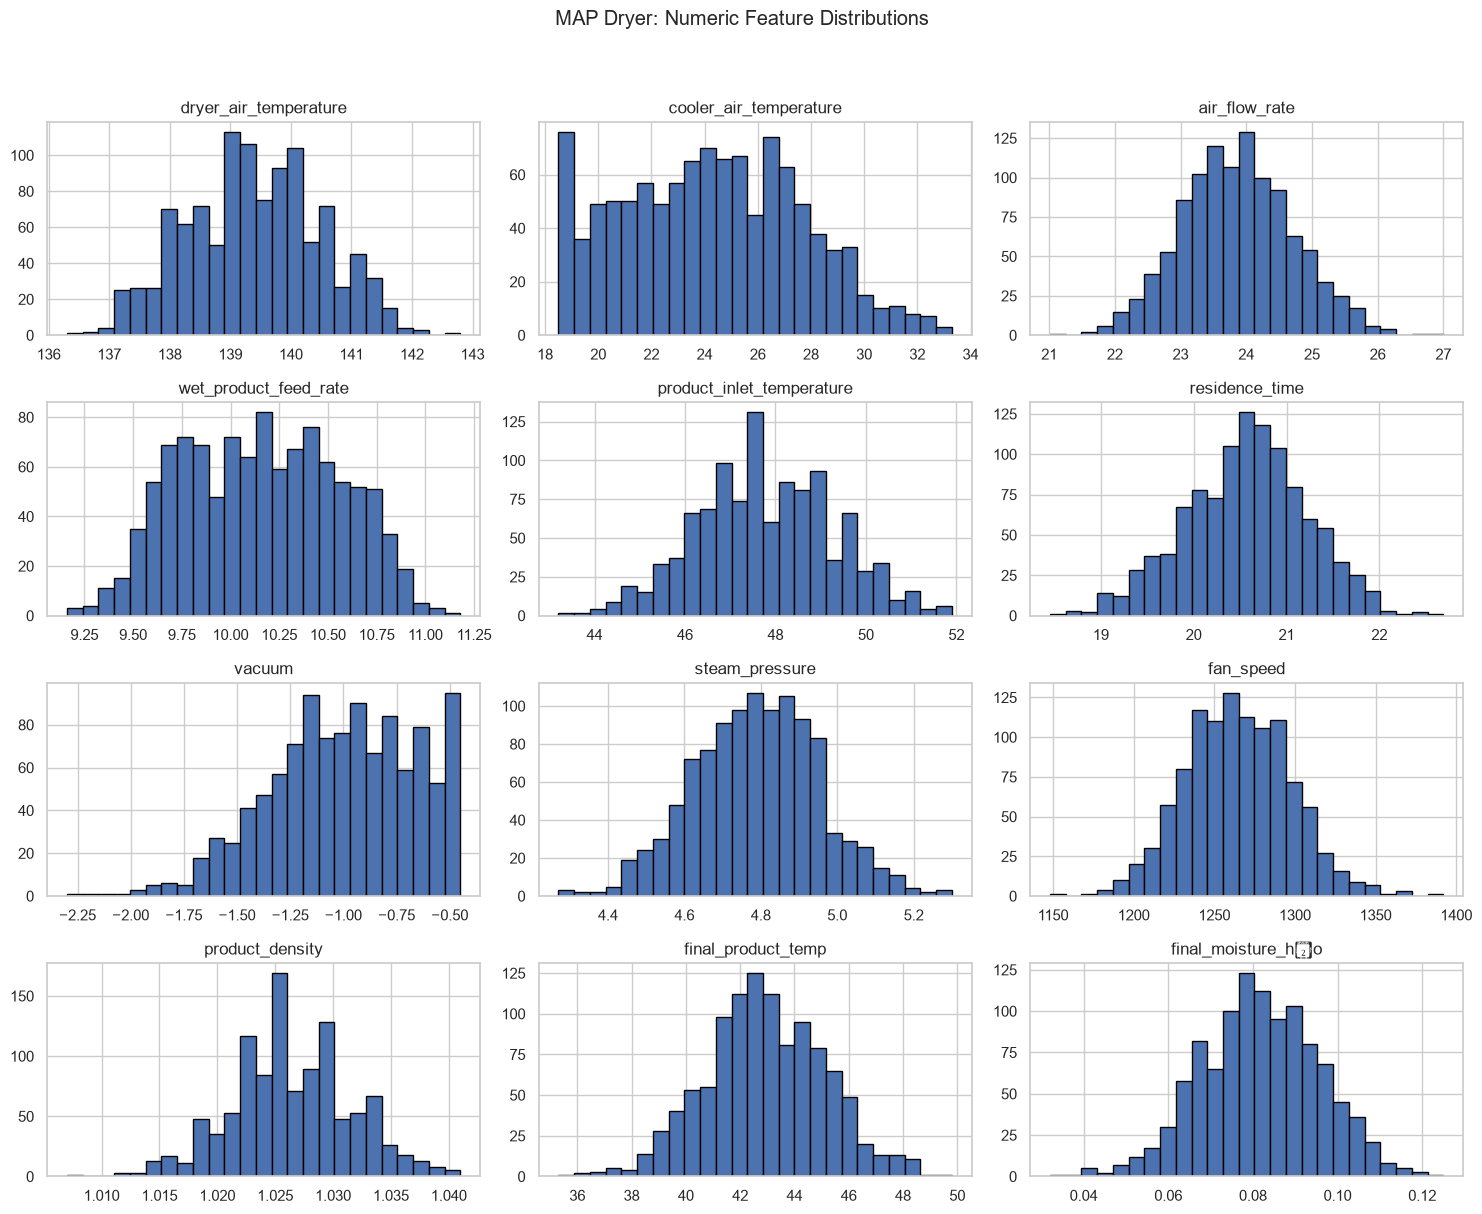

In [8]:
feature_columns =  dryerMAP_unique.select_dtypes(include="number").columns

dryerMAP_unique[feature_columns].hist(figsize=(15, 12), bins=25, edgecolor="black")
plt.suptitle("MAP Dryer: Numeric Feature Distributions", y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(
    FIGURE_OUTPUT_DIR / "01_numeric_feature_distributions.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Next step

Continue with **Notebook 02: Feature Engineering**, which reads the deduplicated file, standardises modelling fields, creates process-informed features, and exports a model-ready table.